In [ ]:
import pandas as pd

# Cargamos el archivo 
path = r"D:\Descargas\Entregable 1 - Documentación extra (1).xlsx"
df = pd.read_excel(path, index_col=0)



In [3]:
# Ver tipos de datos y memoria usada
print(df.info())

# Contar cuántos valores nulos hay por columna
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 129975 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                129912 non-null  object 
 1   description            129973 non-null  object 
 2   designation            90403 non-null   object 
 3   points                 127071 non-null  float64
 4   price                  118213 non-null  object 
 5   province               127010 non-null  object 
 6   region_1               106391 non-null  object 
 7   region_2               49496 non-null   object 
 8   taster_name            101227 non-null  object 
 9   taster_twitter_handle  96267 non-null   object 
 10  title                  127071 non-null  object 
 11  variety                127014 non-null  object 
 12  winery                 127013 non-null  object 
dtypes: float64(1), object(12)
memory usage: 13.9+ MB
None
country                     63
descripti

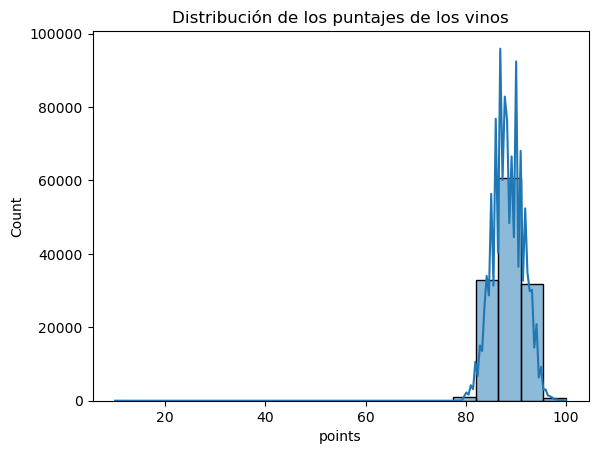

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['points'], bins=20, kde=True)
plt.title('Distribución de los puntajes de los vinos')
plt.show()

In [5]:

# Como ahora tenemos NaNs donde falló la conversión, conviene borrarlos para el gráfico
df_clean = df.dropna(subset=['price', 'points'])

# Tip extra: El punto que ves allá por el '10' es un outlier o error. 
# Filtremos para ver solo lo que tiene sentido (puntos > 70)
df_clean = df_clean[df_clean['points'] > 70]

In [6]:
# 1. Convertimos a numérico forzando errores a NaN
# Esto va a transformar "California" en un valor nulo (NaN) automáticamente
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['points'] = pd.to_numeric(df['points'], errors='coerce')

# 2. Eliminamos las filas donde el precio o los puntos sean NaN
# Esto limpia la fila 'anti-Chardonnay' y cualquier otra que esté rota
df_clean = df.dropna(subset=['price', 'points']).copy()

# 3. Filtramos rangos lógicos
# Los puntos en este dataset van de 80 a 100. Cualquier cosa menor es un error de carga.
df_clean = df_clean[df_clean['points'] >= 80]

print(f"Pasamos de {len(df)} a {len(df_clean)} filas limpias.")

Pasamos de 129975 a 118212 filas limpias.


In [7]:
# Eliminar filas donde el precio es nulo (vital para análisis de costo/beneficio)
df = df.dropna(subset=['price'])

# Rellenar valores nulos en 'designation' o 'region_1' con "Unknown"
df['region_1'] = df['region_1'].fillna('Unknown')

In [8]:
print(df_clean[['points', 'price']].corr())

          points     price
points  1.000000  0.414995
price   0.414995  1.000000


In [ ]:
import pandas as pd

# 1. Eliminar filas donde el precio es nulo 
# (Sin precio no hay análisis de relación calidad-precio)
df_cleaned = df.dropna(subset=['price'])

# 2. Gestionar columnas con nulos masivos
# Eliminamos region_2 porque tiene casi un 60% de nulos (según tu captura)
df_cleaned = df_cleaned.drop(columns=['region_2'])

# 3. Rellenar nulos en columnas categóricas importantes
# Usamos 'Unknown' para no perder la fila pero identificar que falta el dato
cols_to_fix = ['country', 'designation', 'province', 'region_1', 'taster_name', 'taster_twitter_handle']
for col in cols_to_fix:
    df_cleaned[col] = df_cleaned[col].fillna('Unknown')

# 4. Eliminar duplicados
df_cleaned = df_cleaned.drop_duplicates(subset=['description'])

# Verificamos que ahora los nulos críticos sean 0
print(df_cleaned.isnull().sum())

country                   0
description               0
designation               0
points                    0
price                     0
province                  0
region_1                  0
taster_name               0
taster_twitter_handle     0
title                     0
variety                  50
winery                   50
dtype: int64


In [11]:
df.reset_index(drop=True, inplace=True)
print(df.isnull().sum())

country                     58
description                  0
designation              34035
points                       0
price                        0
province                    58
region_1                     0
region_2                 68934
taster_name              24118
taster_twitter_handle    29030
title                        0
variety                     53
winery                      53
dtype: int64


In [14]:
df.sort_values('price', ascending=False).head(5)

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
72956,France,This ripe wine shows plenty of blackberry frui...,NaN,88.0,3300.0,Bordeaux,MÃ©doc,NaN,Roger Voss,@vossroger,ChÃ¢teau les Ormes Sorbet 2013 MÃ©doc,Bordeaux-style Red Blend,ChÃ¢teau les Ormes Sorbet
14435,France,The wine is a velvet glove in an iron fist. Th...,NaN,96.0,2500.0,Bordeaux,Pomerol,NaN,Roger Voss,@vossroger,ChÃ¢teau PÃ©trus 2014 Pomerol,Bordeaux-style Red Blend,ChÃ¢teau PÃ©trus
89428,France,"A superb wine from a great year, this is power...",NaN,96.0,2500.0,Burgundy,La RomanÃ©e,NaN,Roger Voss,@vossroger,Domaine du Comte Liger-Belair 2010 La RomanÃ©e,Pinot Noir,Domaine du Comte Liger-Belair
109432,US,The nose on this single-vineyard wine from a s...,Roger Rose Vineyard,91.0,2013.0,California,Arroyo Seco,Central Coast,Matt Kettmann,@mattkettmann,Blair 2013 Roger Rose Vineyard Chardonnay (Arr...,Chardonnay,Blair
59292,France,This extravagantly perfumed wine has great jui...,NaN,97.0,2000.0,Bordeaux,Pomerol,NaN,Roger Voss,@vossroger,ChÃ¢teau PÃ©trus 2011 Pomerol,Bordeaux-style Red Blend,ChÃ¢teau PÃ©trus


In [16]:
# Calcular el precio promedio por punto para cada país
df['price_per_point'] = df['price'] / df['points']
ranking_paises = df.groupby('country')['price_per_point'].mean().sort_values()
print(ranking_paises.head(10))

country
Ukraine                   0.109741
Bosnia and Herzegovina    0.144652
India                     0.147356
Armenia                   0.165687
Bulgaria                  0.165714
Romania                   0.175782
Macedonia                 0.179452
Slovakia                  0.183908
Cyprus                    0.186553
Moldova                   0.190464
Name: price_per_point, dtype: float64


In [17]:
# Filtrar solo países con una cantidad significativa de reseñas
paises_relevantes = df['country'].value_counts()[df['country'].value_counts() > 100].index
ranking_filtrado = df[df['country'].isin(paises_relevantes)].groupby('country')['price_per_point'].mean().sort_values()

print(ranking_filtrado.head(10))

country
Bulgaria        0.165714
Romania         0.175782
Chile           0.233284
Greece          0.255756
Argentina       0.271634
South Africa    0.275653
Portugal        0.289186
Uruguay         0.302230
New Zealand     0.302400
Spain           0.308574
Name: price_per_point, dtype: float64


In [18]:
# Estadísticas básicas de puntos y precio
stats_puntos = df['points'].describe()
stats_precio = df['price'].describe()

print(f"Calidad promedio: {stats_puntos['mean']:.2f} puntos")
print(f"Precio promedio: {stats_precio['mean']:.2f} USD")
print(f"Vino más caro: {stats_precio['max']} USD")
print(f"Vino más barato: {stats_precio['min']} USD")

Calidad promedio: 88.41 puntos
Precio promedio: 35.27 USD
Vino más caro: 3300.0 USD
Vino más barato: 4.0 USD


In [19]:
# Filtrar países con más de 10 reseñas para que el dato sea confiable
paises_con_volumen = df['country'].value_counts()[df['country'].value_counts() > 10].index

# Ranking de los 10 mejores (más baratos por punto)
ranking_eficiencia = df[df['country'].isin(paises_con_volumen)].groupby('country')['price_per_point'].mean().sort_values()

print("Top 10 Países con mejor relación calidad-precio:")
print(ranking_eficiencia.head(10))

Top 10 Países con mejor relación calidad-precio:
country
Ukraine      0.109741
Bulgaria     0.165714
Romania      0.175782
Macedonia    0.179452
Cyprus       0.186553
Moldova      0.190464
Peru         0.217086
Morocco      0.220222
Georgia      0.220428
Chile        0.233284
Name: price_per_point, dtype: float64


In [ ]:

joyas_ocultas = df[(df['points'] >= 90) & (df['price'] <= 20)]

print(f"Se encontraron {len(joyas_ocultas)} joyas ocultas en el dataset.")
print("Ejemplos de vinos con excelente relación calidad-precio:")
print(joyas_ocultas[['title', 'country', 'points', 'price']].head(5))

Se encontraron 5183 joyas ocultas en el dataset.
Ejemplos de vinos con excelente relación calidad-precio:
                                            title country  points  price
118   Pierre Sparr 2008 Alsace One White (Alsace)  France    91.0   13.0
119          Kuentz-Bas 2008 Pinot Blanc (Alsace)  France    91.0   17.0
122      Dopff & Irion 2008 Gentil White (Alsace)  France    91.0   20.0
128  Dopff & Irion 2008 CrustacÃ©s White (Alsace)  France    90.0   10.0
131  Banyan 2007 Riesling (Santa Lucia Highlands)      US    90.0   17.0


In [21]:
correlacion = df['points'].corr(df['price'])

print(f"La correlación entre precio y puntaje es de: {correlacion:.2f}")# (Si está cerca de 0.4 - 0.6, es una correlación moderada)

La correlación entre precio y puntaje es de: 0.41


Gráfico generado con éxito.


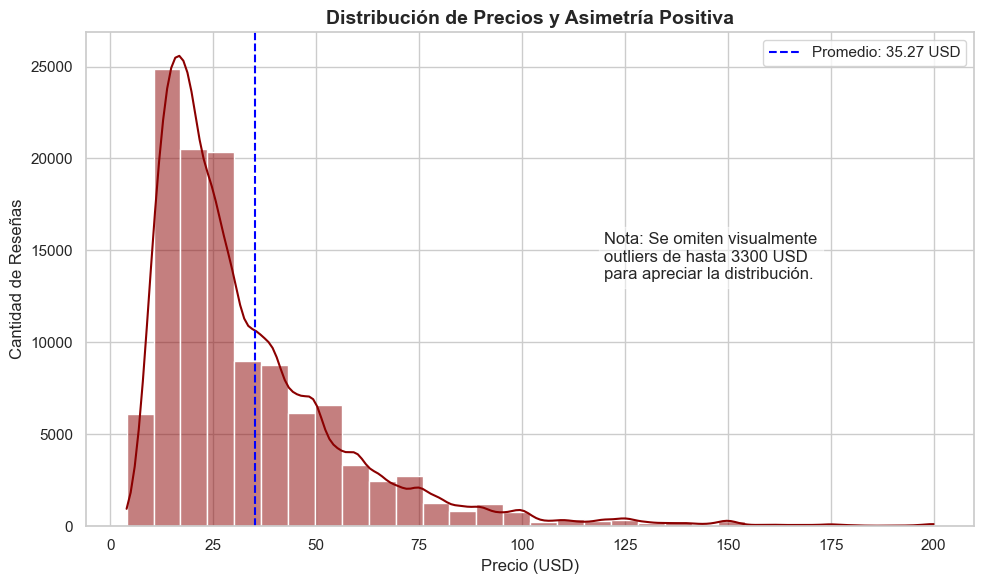

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


# Filtramos visualmente hasta 200 USD para que se vea la "asimetría"
# Si ponemos los 3300 USD, el gráfico quedaría comprimido en una sola línea.
df_plot = df[df['price'] <= 200]

sns.histplot(df_plot['price'], kde=True, color='darkred', bins=30)


promedio = 35.27
plt.axvline(promedio, color='blue', linestyle='--', label=f'Promedio: {promedio} USD')

# 4. Títulos y etiquetas (usando los datos de tu texto)
plt.title('Distribución de Precios y Asimetría Positiva', fontsize=14, fontweight='bold')
plt.xlabel('Precio (USD)', fontsize=12)
plt.ylabel('Cantidad de Reseñas', fontsize=12)

plt.text(120, plt.gca().get_ylim()[1]*0.5, 
         f'Nota: Se omiten visualmente\noutliers de hasta 3300 USD\npara apreciar la distribución.', 
         bbox=dict(facecolor='white', alpha=0.5))

plt.legend()
plt.tight_layout()


plt.savefig('grafico_asimetria_precios.png')
print("Gráfico generado con éxito.")

C:\Users\Globulito.DESKTOP-FK4RDU3.000\AppData\Local\Temp\ipykernel_7216\2911029242.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Índice Eficiencia', y='País', data=df_ranking, palette='YlGnBu_r')


Gráfico generado y guardado como 'ranking_eficiencia_paises.png'


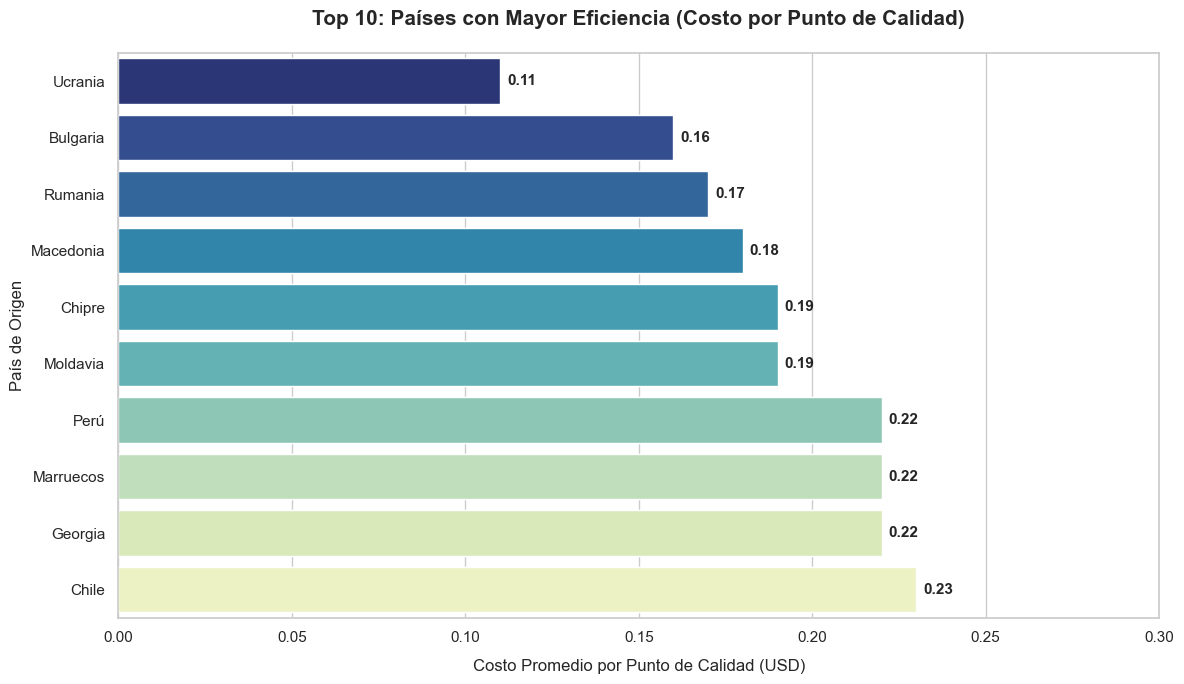

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


data = {
    'País': ['Ucrania', 'Bulgaria', 'Rumania', 'Macedonia', 'Chipre', 'Moldavia', 'Perú', 'Marruecos', 'Georgia', 'Chile'],
    'Índice Eficiencia': [0.11, 0.16, 0.17, 0.18, 0.19, 0.19, 0.22, 0.22, 0.22, 0.23]
}

df_ranking = pd.DataFrame(data)

# Configuración de estilo profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Crear el gráfico de barras horizontales con una paleta degradada
ax = sns.barplot(x='Índice Eficiencia', y='País', data=df_ranking, palette='YlGnBu_r')

# Añadir las etiquetas de los valores al final de cada barra
for i in ax.containers:
    ax.bar_label(i, padding=5, fontsize=11, fontweight='bold')

# Títulos y etiquetas personalizados
plt.title('Top 10: Países con Mayor Eficiencia (Costo por Punto de Calidad)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Costo Promedio por Punto de Calidad (USD)', fontsize=12, labelpad=10)
plt.ylabel('País de Origen', fontsize=12)

# Ajustar el límite 
plt.xlim(0, 0.3)
plt.tight_layout()


ax = sns.barplot(
    x='Índice Eficiencia', 
    y='País', 
    data=df_ranking, 
    palette='YlGnBu_r', 
    hue='País',      # <--- Agregamos esto (repetimos la variable de 'y')
    legend=False     # <--- Y esto para que no te cree una leyenda innecesaria
)


plt.savefig('ranking_eficiencia_paises.png', dpi=300)
print("Gráfico generado y guardado como 'ranking_eficiencia_paises.png'")


Gráfico generado con éxito.


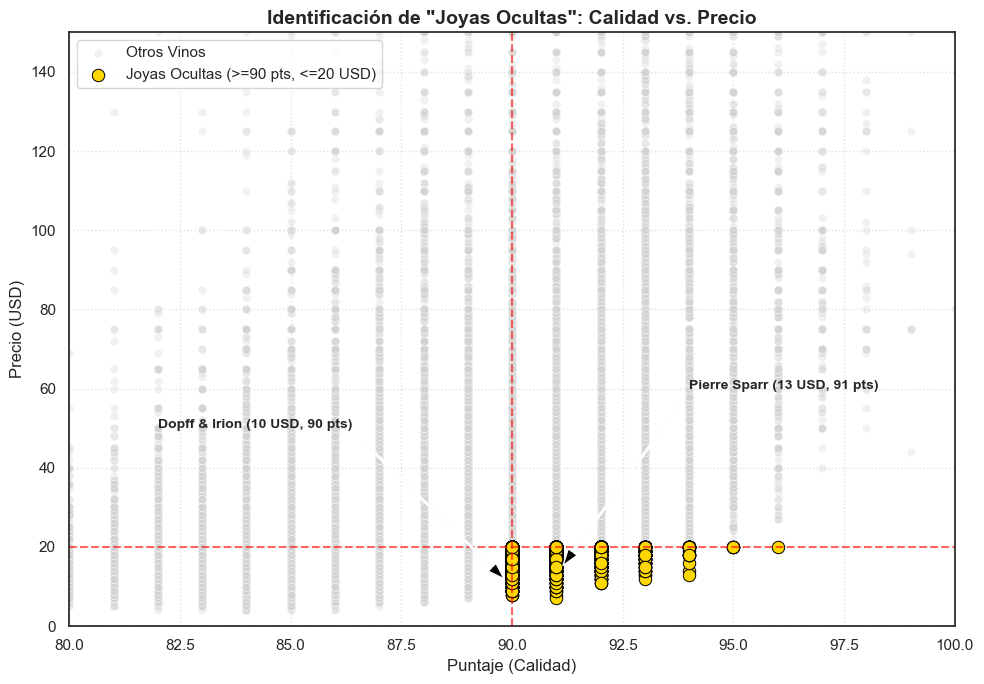

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar los datos para las "Joyas Ocultas"
joyas_ocultas = df[(df['points'] >= 90) & (df['price'] <= 20)]

# Configuración de estilo profesional
sns.set_theme(style="white")
plt.figure(figsize=(10, 7))

# Graficar todos los vinos en gris claro para que sirvan de fondo
sns.scatterplot(data=df, x='points', y='price', color='lightgrey', alpha=0.3, label='Otros Vinos')

# 3. Graficar las Joyas Ocultas en dorado para resaltarlas
sns.scatterplot(data=joyas_ocultas, x='points', y='price', color='gold', edgecolor='black', s=80, label='Joyas Ocultas (>=90 pts, <=20 USD)')

# 4. Dibujar líneas de referencia para el cuadrante de interés
plt.axvline(x=90, color='red', linestyle='--', alpha=0.6)
plt.axhline(y=20, color='red', linestyle='--', alpha=0.6)

# Anotaciones para los casos disruptivos mencionados en tu texto
# Nota: xy son las coordenadas del punto, xytext es donde va el texto
plt.annotate('Dopff & Irion (10 USD, 90 pts)', xy=(90, 10), xytext=(82, 50),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, fontweight='bold')

plt.annotate('Pierre Sparr (13 USD, 91 pts)', xy=(91, 13), xytext=(94, 60),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, fontweight='bold')

# Personalización de títulos y ejes
plt.title('Identificación de "Joyas Ocultas": Calidad vs. Precio', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje (Calidad)', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)


plt.xlim(80, 100)
plt.ylim(0, 150) 
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('joyas_ocultas_grafico.png', dpi=300)
print("Gráfico generado con éxito.")

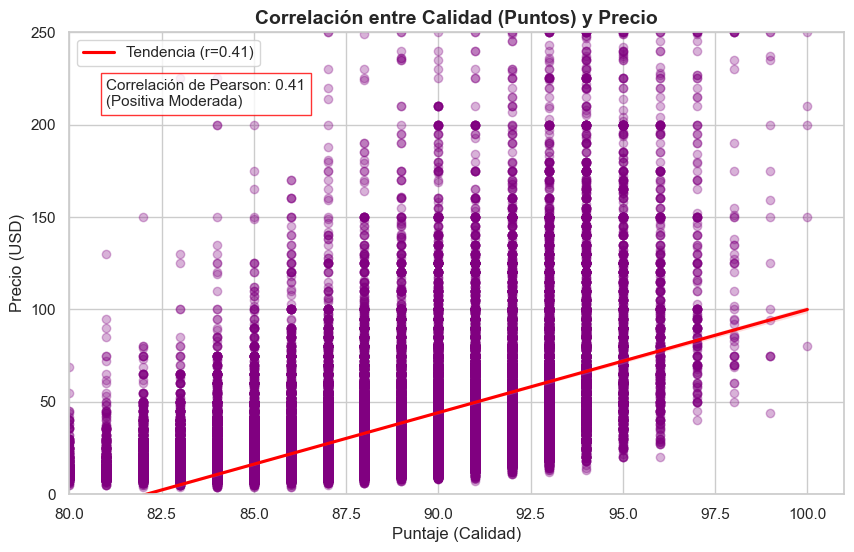

Gráfico generado con éxito y sin márgenes sobrantes.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

#Gráfico de Regresión
ax = sns.regplot(data=df, x='points', y='price', 
                 scatter_kws={'alpha':0.3, 'color':'purple'}, 
                 line_kws={'color':'red', 'label':'Tendencia (r=0.41)'})

#Personalización de ejes y títulos
plt.title('Correlación entre Calidad (Puntos) y Precio', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje (Calidad)', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)


# En lugar de usar df['price'].max(), usamos 210 para que el texto 
# aparezca dentro del área visible (0-250)
plt.text(81, 210, 'Correlación de Pearson: 0.41\n(Positiva Moderada)', 
         fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

# 4. Limitamos el eje Y
plt.ylim(0, 250) 
plt.xlim(80, 101)

plt.legend()


plt.savefig('grafico_correlacion_limpio.png', dpi=300, bbox_inches='tight')

plt.show() 
print("Gráfico generado con éxito")
